<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/ECO007.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

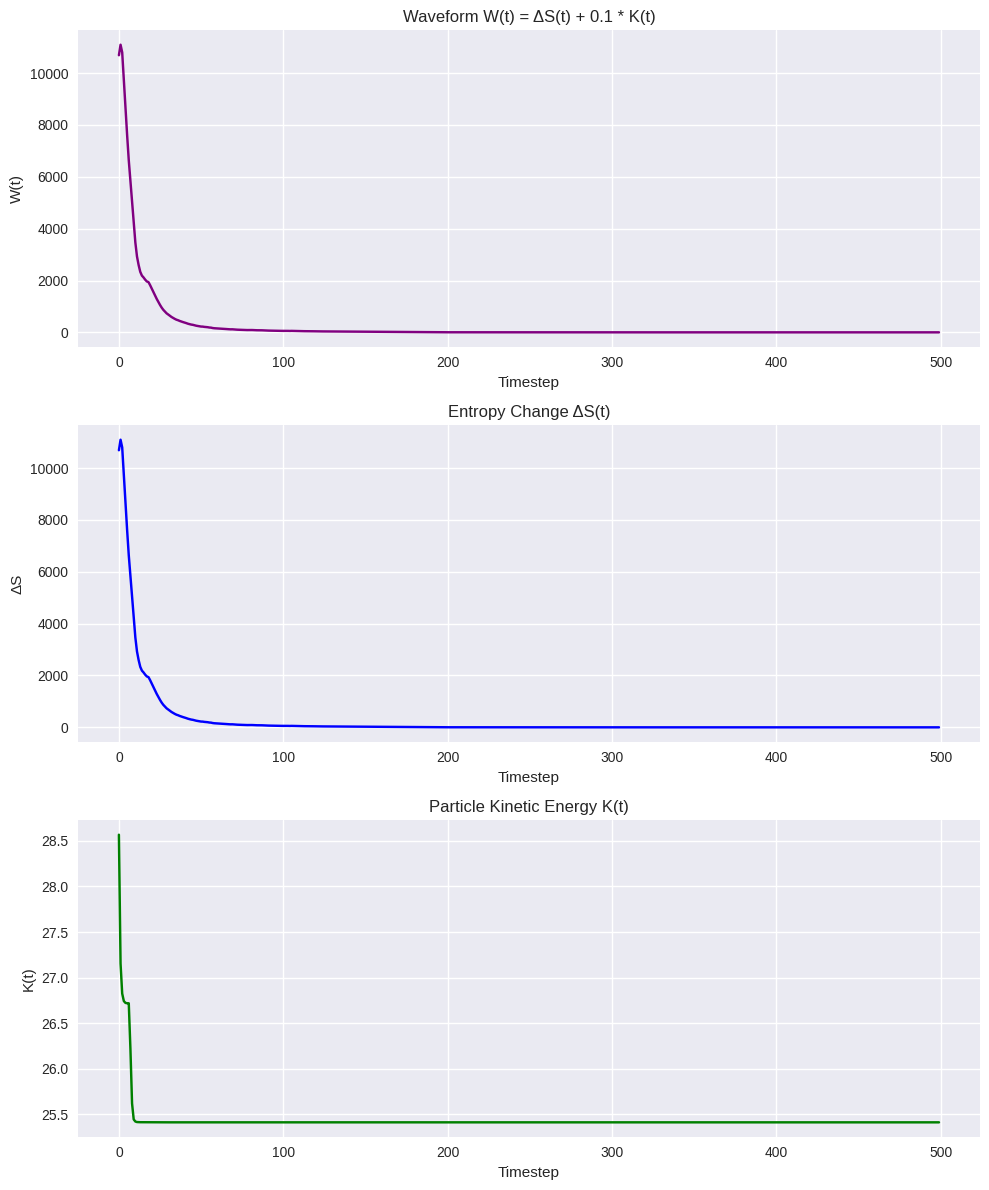

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
N = 100
timesteps = 500
alpha = 2.0
beta = 0.1
num_particles = 50

# Shell entropy field
def shell_entropy(N, center, radius=30):
    x = np.linspace(0, N-1, N)
    grid = np.meshgrid(x, x, x)
    r2 = sum((g - c)**2 for g, c in zip(grid, center))
    shell = np.exp(-((np.sqrt(r2) - radius)**2) / 50)
    return shell / np.max(shell)

# Gaussian entropy field
def gaussian_entropy(N, center):
    x = np.linspace(0, N-1, N)
    grid = np.meshgrid(x, x, x)
    r2 = sum((g - c)**2 for g, c in zip(grid, center))
    gaussian = np.exp(-r2 / 100)
    return gaussian / np.max(gaussian)

# Initialize particles
def initialize_particles(num, N):
    positions = np.random.randint(0, N, size=(num, 3))
    velocities = np.random.randn(num, 3) * 0.5
    return positions, velocities

# Simulation loop
def simulate_echo(entropy, alpha, beta, positions, velocities):
    delta_S = []
    fidelity = []
    kinetic_energy = []

    for t in range(timesteps):
        gradient = np.gradient(entropy)
        magnitude = np.sqrt(sum(g**2 for g in gradient))
        non_zero_mag = magnitude[magnitude > 1e-9]
        if non_zero_mag.size == 0:
            break
        mu_grad = np.mean(non_zero_mag)
        sigma_grad = np.std(non_zero_mag)
        threshold = alpha * mu_grad + beta * sigma_grad

        collapse_mask = magnitude > threshold
        entropy_before = np.sum(entropy)
        entropy[collapse_mask] *= 0.9
        entropy_after = np.sum(entropy)

        delta_S.append(entropy_before - entropy_after)
        fidelity.append(np.sum(collapse_mask))

        # Particle update
        for i in range(len(positions)):
            pos = positions[i]
            vel = velocities[i]
            new_pos = np.clip(pos + vel.astype(int), 0, N-1)
            if collapse_mask[tuple(new_pos)]:
                velocities[i] *= 0.5
            positions[i] = new_pos

        kinetic_energy.append(np.sum(velocities**2))

        if entropy_after < 1e-6:
            break

    waveform = np.array(delta_S) + 0.1 * np.array(kinetic_energy)
    return delta_S, fidelity, kinetic_energy, waveform

# Create dual-field entropy
shell = shell_entropy(N, center=(50, 50, 50))
gaussian = gaussian_entropy(N, center=(70, 70, 70))
entropy = shell + gaussian

# Initialize particles
positions, velocities = initialize_particles(num_particles, N)

# Run simulation
delta_S, fidelity, kinetic_energy, waveform = simulate_echo(
    entropy.copy(), alpha, beta, positions, velocities
)

# Plot results
plt.style.use('seaborn-v0_8')
fig, axs = plt.subplots(3, 1, figsize=(10, 12))

axs[0].plot(waveform, color='purple')
axs[0].set_title("Waveform W(t) = ΔS(t) + 0.1 * K(t)")
axs[0].set_xlabel("Timestep")
axs[0].set_ylabel("W(t)")

axs[1].plot(delta_S, color='blue')
axs[1].set_title("Entropy Change ΔS(t)")
axs[1].set_xlabel("Timestep")
axs[1].set_ylabel("ΔS")

axs[2].plot(kinetic_energy, color='green')
axs[2].set_title("Particle Kinetic Energy K(t)")
axs[2].set_xlabel("Timestep")
axs[2].set_ylabel("K(t)")

plt.tight_layout()
plt.show()
